## Create Channel + Large Scale Fading

In [ ]:
import numpy as np
from scipy.io import savemat, loadmat

# Function to create a circular cell layout (unchanged)
def cell_circle(x0, y0, radius):
    th = np.linspace(0, 2 * np.pi, 100)
    x = radius * np.cos(th) + x0
    y = radius * np.sin(th) + y0
    return x, y, x0, y0

# Function to create a hexagonal cell layout (unchanged)
def cell_hexagon(x0, y0, cote):
    x = cote * np.array([0, 1, 1, 0, -1, -1, 0]) * np.sqrt(3) / 2 + x0
    y = cote * np.array([1, 0.5, -0.5, -1, -0.5, 0.5, 1]) + y0
    return x, y, x0, y0

# Function to generate base station and user locations (unchanged)
def location_bs_user(num_users, rad_bs):
    x0, y0 = 0, 0
    x, y, XBS, YBS = cell_circle(x0, y0, rad_bs)

    Dtempt_Users = 200 * np.sqrt(np.random.rand(num_users)) + 250
    Angtemp_Users = np.random.rand(num_users) * 2 * np.pi
    X_Users = Dtempt_Users * np.cos(Angtemp_Users)
    Y_Users = Dtempt_Users * np.sin(Angtemp_Users)

    return XBS, YBS, X_Users, Y_Users

# New function to generate the UAV locations
def generate_uav_locations(num_uavs, height, radius):
    Dtempt_UAVs = radius * np.sqrt(np.random.rand(num_uavs))
    Angtemp_UAVs = np.random.rand(num_uavs) * 2 * np.pi
    X_UAVs = Dtempt_UAVs * np.cos(Angtemp_UAVs)
    Y_UAVs = Dtempt_UAVs * np.sin(Angtemp_UAVs)
    Z_UAVs = np.ones(num_uavs) * height  # All UAVs have the same height

    return X_UAVs, Y_UAVs, Z_UAVs

# Modified path loss function to handle multiple UAVs
def func_path_multiple_uavs(num_uavs, num_users, X_UAVs, Y_UAVs, Z_UAVs, X_Users, Y_Users, Wband, eta, L, sigma_n):
    pl_exponent = 3  # path-loss exponent
    beta_0 = 10 ** (-30 / 10)  # Channel power gain at the reference distance
    a = 11.95
    b = 0.136
    gamma = 10 ** (20 / 10)  # The excessive attenuation factor

    # Create a matrix to store the path loss between each UAV and each user
    UAV_User_path = np.zeros((num_uavs, num_users))

    # Loop over each UAV and each user to calculate the path loss
    for uav in range(num_uavs):
        for user in range(num_users):
            # Calculate the angle phi (elevation angle)
            distance = np.sqrt((X_Users[user] - X_UAVs[uav]) ** 2 +
                               (Y_Users[user] - Y_UAVs[uav]) ** 2 +
                               Z_UAVs[uav] ** 2)
            phi = np.degrees(np.arcsin(Z_UAVs[uav] / distance))

            # Calculate probabilities of LOS and NLOS
            Pr_los = 1 / (1 + a * np.exp(-b * (phi - a)))
            Pr_nlos = 1 - Pr_los

            # Calculate path loss for LOS and NLOS
            UAV_User_path[uav, user] = Pr_los * (distance) ** (-4) + Pr_nlos * gamma * (distance) ** (-4)

    return UAV_User_path

# Main function to run the simulation with multiple UAVs
def main():
    # Simulation parameters
    Wband = 20e6  # MHz
    RadBS = 1000  # radius coverage in meters
    height = 200  # height of UAVs in meters
    NumUsers_ref = 35  # number of users
    NumUAVs = 40  # number of UAVs
    eta = 0.5  # energy harvesting efficiency (not used)
    L = 1  # number of antennas at each user
    Noise_var = 10 ** (-130 / 10) * Wband * 10 ** 6  # noise variance
    sigma_n = Noise_var  # set noise variance

    # Generate the location of the base station and users
    XBS, YBS, X_Users, Y_Users = location_bs_user(NumUsers_ref, RadBS)

    # Generate the locations of multiple UAVs
    X_UAVs, Y_UAVs, Z_UAVs = generate_uav_locations(NumUAVs, height, RadBS)

    # Save the location data into a .mat file
    savemat('channel1.mat', {
        'XBS': XBS,
        'YBS': YBS,
        'X_Users': X_Users,
        'Y_Users': Y_Users,
        'X_UAVs': X_UAVs,
        'Y_UAVs': Y_UAVs,
        'Z_UAVs': Z_UAVs
    })

    # Calculate the path loss between each UAV and each user
    UAV_User_path = func_path_multiple_uavs(NumUAVs, NumUsers_ref, X_UAVs, Y_UAVs, Z_UAVs, X_Users, Y_Users, Wband, eta, L, sigma_n)

    # Save the path loss data into a .mat file
    savemat('uavuserpath1.mat', {
        'UAV_User_path': UAV_User_path
    })

    print("Data saved to channel.mat and uavuserpath.mat")

if __name__ == "__main__":
    main()


Data saved to channel.mat and uavuserpath.mat


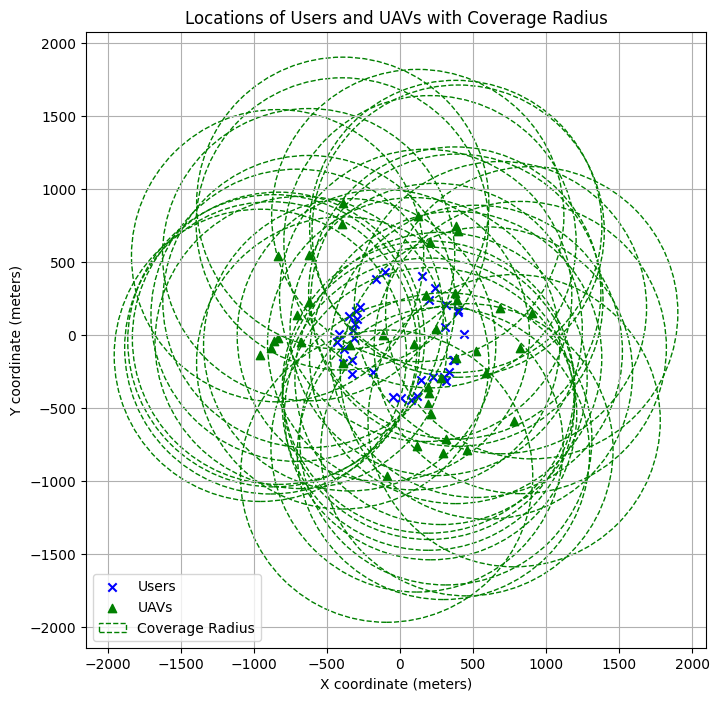

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# Function to plot the UAVs and users on a 2D plane with coverage radius
def plot_uav_user_locations_with_radius(channel_file, uav_user_path_file, radius):
    # Load the .mat files
    channel_data = loadmat(channel_file)
    uav_user_path_data = loadmat(uav_user_path_file)

    # Extract locations of users and UAVs
    X_Users = channel_data['X_Users'][0]
    Y_Users = channel_data['Y_Users'][0]
    X_UAVs = channel_data['X_UAVs'][0]
    Y_UAVs = channel_data['Y_UAVs'][0]
    Z_UAVs = channel_data['Z_UAVs'][0]

    # Create a plot
    plt.figure(figsize=(8, 8))

    # Plot the users' locations
    plt.scatter(X_Users, Y_Users, c='blue', marker='x', label='Users')

    # Plot the UAVs' locations
    plt.scatter(X_UAVs, Y_UAVs, c='green', marker='^', label='UAVs')

    # Plot the coverage radius for each UAV
    for x_uav, y_uav in zip(X_UAVs, Y_UAVs):
        circle = plt.Circle((x_uav, y_uav), radius, color='green', fill=False, linestyle='--', label='Coverage Radius' if x_uav == X_UAVs[0] else "")
        plt.gca().add_patch(circle)

    # Add labels and title
    plt.title('Locations of Users and UAVs with Coverage Radius')
    plt.xlabel('X coordinate (meters)')
    plt.ylabel('Y coordinate (meters)')
    plt.grid(True)

    plt.axis('equal')
    plt.legend()
    plt.show()

# Main function to load data and plot the locations
def main():
    channel_file = 'channel1.mat'
    uav_user_path_file = 'uavuserpath1.mat'

    # Define the coverage radius
    coverage_radius = 1000

    # Plot the locations of UAVs and users with the coverage radius
    plot_uav_user_locations_with_radius(channel_file, uav_user_path_file, coverage_radius)

if __name__ == "__main__":
    main()


## Worst Case Data-rate

10
15
20
25
30
35


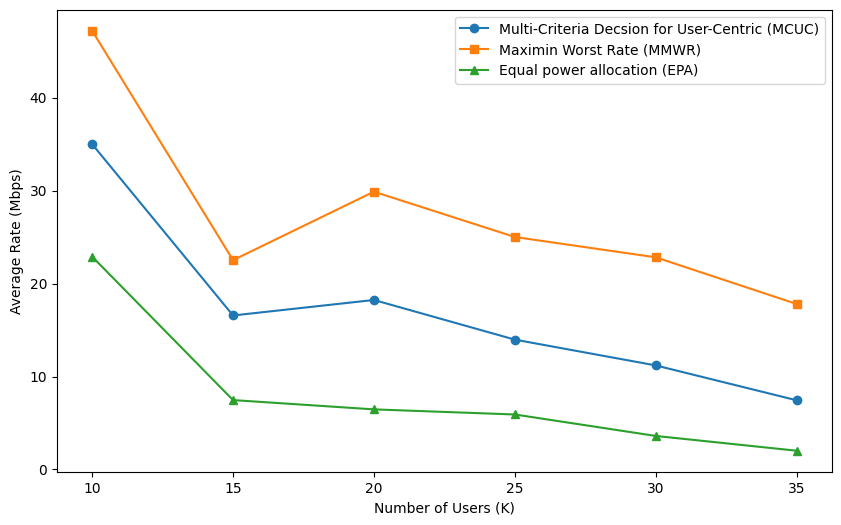

In [ ]:
import numpy as np
import cvxpy as cp
from scipy.io import loadmat
import matplotlib.pyplot as plt

# Parameters
M = 40  # Number of UAVs (USCs)
N = 20  # Number of antennas per UAV
Wband = 20e6  # Bandwidth = 20 MHz
total_power_mW = 200  # Total available power in mW
no_Monte = 5 # Number of Monte Carlo trials

# Load the .mat files containing location and path loss data
channel_data = loadmat('channel1.mat')
uav_user_path_data = loadmat('uavuserpath1.mat')

# Path loss data between UAVs and users
UAV_User_path = uav_user_path_data['UAV_User_path']
Noise_var = 290 * 1.38e-23 * Wband * 10**(9/10)  # Noise variance

# Compute beta_mk (large-scale fading)
beta_mk = UAV_User_path / Noise_var

# Define the user counts to test
user_counts = [10,15,20,25,30,35]
control_alpha = [0.01,0.007,0.005,0.004, 0.0033,0.0028]
# Initialize the result arrays to store average rates for each case
average_rates_case1 = []
average_rates_case2 = []
average_rates_case3 = []
average_rates_case4 = []

# Monte Carlo simulation
for K in user_counts:
    print(K)
    # Initialize the result arrays to store rates for the user with the worst channel for this K
    worst_user_rates_case1 = np.zeros(no_Monte)
    worst_user_rates_case2 = np.zeros(no_Monte)
    worst_user_rates_case3 = np.zeros(no_Monte)
    worst_user_rates_case4 = np.zeros(no_Monte)

    for trial in range(no_Monte):
        # Compute the average channel gain (beta_hat) for each user
        beta_hat = np.mean(beta_mk[:K,:K], axis=0)
        # print(beta_hat.shape)
        # Identify the user with the worst channel
        user_k_kenh_te_nhat = np.argmin(beta_hat[:K])

        # Initialize matrix G with zeros for this trial
        G = np.zeros((M * N, K), dtype=complex)

        # Build the full G matrix for each UAV and user
        for m in range(M):
            h_mk = (1 / np.sqrt(2)) * (np.random.randn(N, K) + 1j * np.random.randn(N, K))
            g_mk = np.sqrt(beta_mk[m, :K]) * h_mk
            G[m * N: (m + 1) * N, :] = g_mk
            savemat('small_scale.mat', {
                'h_mk': h_mk})

        # Compute the Zero-Forcing beamforming matrix
        G_H = np.conjugate(G.T)
        GG_H = np.dot(G, G_H)
        GG_H_inv = np.linalg.inv(GG_H)
        Vzf = np.dot(G_H, GG_H_inv)


        gamma_k_list = []

        for k in range(K):
            G_k = G[:, k]  # Use the sorted index for each user
            v_k = Vzf.T[:, k]  # ZF beamforming vector for sorted user k
            norm_2 = np.linalg.norm(v_k, 2)
            f_k = (v_k / norm_2).reshape(-1, 1) # 800x1
            # print("f_k : ",f_k.shape)
            # print(G_k.shape)
            # print(f_k.shape)
            gamma_k = np.abs(np.dot(G_k.T, f_k))**2
            # print("gamma_k: ",gamma_k.shape)
            gamma_k_list.append(gamma_k)
        # print(gamma_k_list)
        for k in range (K):
            beta_hat[k] = gamma_k_list[k].item()
        # print(beta_hat)
        # Sort beta_hat and get the sorted indices
        sorted_indices = np.argsort(beta_hat)[::-1]  # Sorting in descending order
        sorted_beta_hat = beta_hat[sorted_indices]
        sort_indice_inv = sorted_indices[::-1]

        # Compute alpha_star based on the sorted beta_hat
        alpha_star = sorted_beta_hat / np.sum(sorted_beta_hat)
        alpha_star_order = np.zeros(K)

        # Re-map
        for k in range(K):
            alpha_star_order[sort_indice_inv[k]] = alpha_star[k]

        # Apply QoS constraint (minimum 0.05 for each channel)
        alpha_star_order = np.maximum(alpha_star_order, control_alpha[user_counts.index(K)])

        # Recalculate the remaining sum after applying the minimum threshold
        remaining_sum = 1 - np.sum(alpha_star_order[alpha_star_order == control_alpha[user_counts.index(K)]])

        # Normalize only the values that are greater than 0.05
        if remaining_sum > 0:
            alpha_star_order[alpha_star_order > control_alpha[user_counts.index(K)]] *= remaining_sum / np.sum(alpha_star_order[alpha_star_order > control_alpha[user_counts.index(K)]])

        # print(alpha_star_order)

        #### Case 1: Fairness of QoS ####
        P1 = cp.Variable(K)
        # sorted_indices = np.argsort(beta_hat)[::-1]  # Sorting in descending order
        # sorted_beta_hat = beta_hat[sorted_indices]
        # sort_indice_inv = sorted_indices[::-1]

        # # Compute alpha_star based on the sorted beta_hat
        # alpha_star = sorted_beta_hat / np.sum(sorted_beta_hat)

        # # Re-map
        # alpha_star_order = np.zeros(K)


        # for k in range(K):
        #     alpha_star_order[sort_indice_inv[k]] = alpha_star[k]


        rate_list_case1 = []
        # Objective and constraints for Case 1
        objective_case1 = 0
        for k in range(K):
            G_k = G[:, k]
            v_k = Vzf.T[:, k]
            norm_2 = np.linalg.norm(v_k, 2)
            f_k = (v_k / norm_2).reshape(-1, 1)
            gamma_k = np.abs(np.dot(G_k.T, f_k))**2 * P1[k]
            rate_k = Wband * cp.log(1 + gamma_k) / np.log(2)
            objective_case1 += alpha_star_order[k] * rate_k

        constraints_case1 = [cp.sum(P1) <= total_power_mW, P1 >= 0]
        problem_case1 = cp.Problem(cp.Maximize(objective_case1), constraints_case1)
        problem_case1.solve()

        # worst_user_rates_case1[trial] = rate_k.item() / 1e6  # Convert to Mbps
        for k in range(K):
            G_k = G[:, k]
            v_k = Vzf.T[:, k]
            norm_2 = np.linalg.norm(v_k, 2)
            f_k = (v_k / norm_2).reshape(-1, 1)
            gamma_k = np.abs(np.dot(G_k.T, f_k))**2 * P1.value[k] /1000
            rate_k = Wband * np.log(1 + gamma_k) / np.log(2)
            rate_list_case1.append(rate_k)
            # print(min(rate_list_case1)/1e6)
        worst_user_rates_case1[trial] = min(rate_list_case1).item() / 1e6

        #### Case 2: Maximin SINR ####
        SINR_min = cp.Variable()
        SINR_list = []
        P2 = cp.Variable(K)
        for k in range(K):
            G_k = G[:, k]
            v_k = Vzf.T[:, k]
            norm_2 = np.linalg.norm(v_k, 2)
            f_k = (v_k / norm_2).reshape(-1, 1)
            SINR_k = np.abs(np.dot(G_k.T, f_k))**2 * P2[k]
            SINR_list.append(SINR_k)

        objective_case2 = cp.Maximize(cp.min(cp.hstack(SINR_list)))
        constraints_case2 = [cp.sum(P2) <= total_power_mW, P2 >= 0]
        problem_case2 = cp.Problem(objective_case2, constraints_case2)
        problem_case2.solve()

        user_with_max_power = np.argmax(P2.value)
        G_k = G[:, user_with_max_power]
        v_k = Vzf.T[:, user_with_max_power]
        norm_2 = np.linalg.norm(v_k, 2)
        f_k = (v_k / norm_2).reshape(-1, 1)
        P_k_watt = P2.value[user_with_max_power] / 1000
        gamma_k = np.abs(np.dot(G_k.T, f_k))**2 * P_k_watt
        rate_k = Wband * np.log(1 + gamma_k) / np.log(2)
        worst_user_rates_case2[trial] = rate_k.item() / 1e6  # Convert to Mbps

        #### Case 3: Equal Power Allocation (EPA) ####
        equal_power_mW = total_power_mW / K
        equal_power_W = equal_power_mW / 1000

        # Compute rate for the worst user in Case 3
        G_k = G[:, user_with_max_power]
        v_k = Vzf.T[:, user_with_max_power]
        norm_2 = np.linalg.norm(v_k, 2)
        f_k = (v_k / norm_2).reshape(-1, 1)

        worst_user_rates_case2[trial] = rate_k.item() / 1e6  # Convert to Mbps
        gamma_k = np.abs(np.dot(G_k.T, f_k))**2 * equal_power_W
        rate_k = Wband * np.log(1 + gamma_k) / np.log(2)

        worst_user_rates_case3[trial] = rate_k.item() / 1e6  # Convert to Mbps

        #### Case 4: Random Power Allocation ####
        random_factors = np.random.rand(K)
        random_power_mW = (random_factors / np.sum(random_factors)) * total_power_mW
        random_power_W = random_power_mW / 1000

        # Compute rate for the worst user in Case 4
        gamma_k = np.abs(np.dot(G_k.T, f_k))**2 * random_power_W[user_with_max_power]
        rate_k = Wband * np.log(1 + gamma_k) / np.log(2)
        worst_user_rates_case4[trial] = rate_k.item() / 1e6  # Convert to Mbps

    # Calculate and store the average rates for this K
    average_rates_case1.append(np.mean(worst_user_rates_case1))
    average_rates_case2.append(np.mean(worst_user_rates_case2))
    average_rates_case3.append(np.mean(worst_user_rates_case3))
    average_rates_case4.append(np.mean(worst_user_rates_case4))

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(user_counts, average_rates_case1, marker='o', label="Multi-Criteria Decsion for User-Centric (MCUC)")
plt.plot(user_counts, average_rates_case2, marker='s', label="Maximin Worst Rate (MMWR)")
plt.plot(user_counts, average_rates_case3, marker='^', label="Equal power allocation (EPA)")
# plt.plot(user_counts, average_rates_case4, marker='x', label="Random power allocation (RPA)")


# Add titles and labels
# plt.title("Average Rate for the User with the Worst Channel Across Different User Counts")
plt.xlabel("Number of Users (K)")
plt.ylabel("Average Rate (Mbps)")
plt.xticks(user_counts)  # Set x-ticks to match the user counts
plt.grid(False)
plt.legend()
plt.savefig("Case1.png")
# Show the plot
plt.show()


## Sum rate Case

10
[array([14296182.49135851]), array([35176060.49299549]), array([53404412.96667313]), array([34018115.92658402]), array([34595893.24908222]), array([46682260.63296878]), array([20426328.14285767]), array([53407658.51771816]), array([35178728.2666145]), array([34598886.93624949])]
200.00000000000003
[array([76938968.22338475]), array([45525153.80488601]), array([30399302.36209607]), array([19906509.08733134]), array([45089269.57713743]), array([60520789.27663109]), array([45523600.02986231]), array([60519809.85854834]), array([45087598.51492415]), array([76935404.7078702])]
200.00000000000006
[array([5436082.19489879]), array([14334829.86358298]), array([8911246.04097328]), array([31606434.68312896]), array([10010837.70114816]), array([41971128.36252571]), array([4461322.64538849]), array([10009732.46652777]), array([8906429.78239563]), array([28349164.2014197])]
200.00000000000006
[array([24151782.96404996]), array([25733054.77809802]), array([28149122.60831572]), array([20930399.841

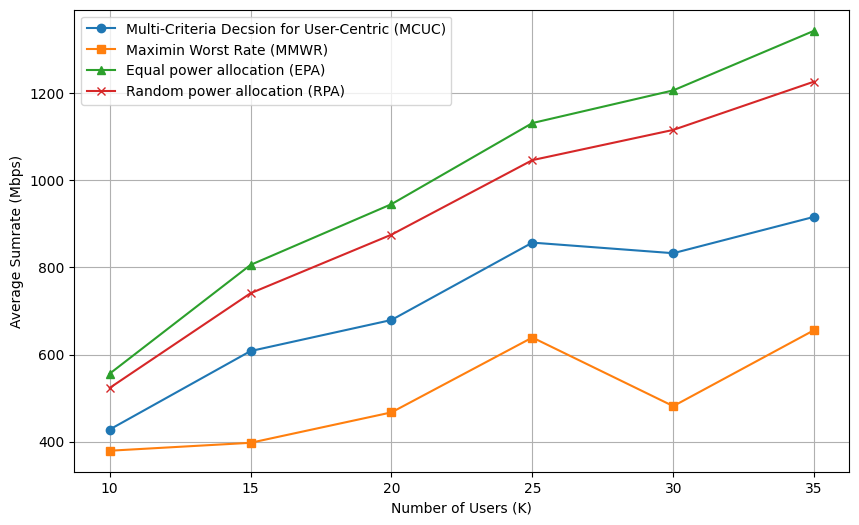

In [ ]:
import numpy as np
import cvxpy as cp
from scipy.io import loadmat
import matplotlib.pyplot as plt
import random
# Parameters
M = 40  # Number of UAVs (USCs)
N = 20  # Number of antennas per UAV
Wband = 20e6  # Bandwidth = 20 MHz
total_power_mW = 200  # Total available power in mW
no_Monte = 20 # Number of Monte Carlo trials

# Load the .mat files containing location and path loss data
channel_data = loadmat('channel1.mat')
uav_user_path_data = loadmat('uavuserpath1.mat')

# Path loss data between UAVs and users
UAV_User_path = uav_user_path_data['UAV_User_path']
Noise_var = 290 * 1.38e-23 * Wband * 10**(9/10)  # Noise variance

# Compute beta_mk (large-scale fading)
beta_mk = UAV_User_path / Noise_var

# Define the user counts to test
user_counts = [10,15,20,25,30,35]
control_alpha = [0.01,0.007,0.005,0.004, 0.0033,0.0028]
# Initialize the result arrays to store average rates for each case
average_rates_case1 = []
average_rates_case2 = []
average_rates_case3 = []
average_rates_case4 = []

# Monte Carlo simulation
for K in user_counts:
    print(K)
    # Initialize the result arrays to store rates for the user with the worst channel for this K
    sum_user_rates_case1 = np.zeros(no_Monte)
    sum_user_rates_case2 = np.zeros(no_Monte)
    sum_user_rates_case3 = np.zeros(no_Monte)
    sum_user_rates_case4 = np.zeros(no_Monte)

    for trial in range(no_Monte):
        # Compute the average channel gain (beta_hat) for each user
        beta_hat = np.mean(beta_mk[:K,:K], axis=0)
        # print(beta_hat.shape)
        # Identify the user with the worst channel
                # Initialize matrix G with zeros for this trial
        G = np.zeros((M * N, K), dtype=complex)


        # Build the full G matrix for each UAV and user
        for m in range(M):
            h_mk = (1 / np.sqrt(2)) * (np.random.randn(N, K) + 1j * np.random.randn(N, K))
            g_mk = np.sqrt(beta_mk[m, :K]) * h_mk
            G[m * N: (m + 1) * N, :] = g_mk

        # Compute the Zero-Forcing beamforming matrix
        G_H = np.conjugate(G.T)
        GG_H = np.dot(G, G_H)
        GG_H_inv = np.linalg.inv(GG_H)
        Vzf = np.dot(G_H, GG_H_inv)


        gamma_k_list = []

        for k in range(K):
            G_k = G[:, k]  # Use the sorted index for each user
            v_k = Vzf.T[:, k]  # ZF beamforming vector for sorted user k
            norm_2 = np.linalg.norm(v_k, 2)
            f_k = (v_k / norm_2).reshape(-1, 1) # 800x1
            # print("f_k : ",f_k.shape)
            # print(G_k.shape)
            # print(f_k.shape)
            gamma_k = np.abs(np.dot(G_k.T, f_k))**2
            # print("gamma_k: ",gamma_k.shape)
            gamma_k_list.append(gamma_k)
        # print(gamma_k_list)
        for k in range (K):
            beta_hat[k] = gamma_k_list[k].item()
        # print(beta_hat)
        # Sort beta_hat and get the sorted indices
        sorted_indices = np.argsort(beta_hat)[::-1]  # Sorting in descending order
        sorted_beta_hat = beta_hat[sorted_indices]
        sort_indice_inv = sorted_indices[::-1]

        # Compute alpha_star based on the sorted beta_hat
        alpha_star = sorted_beta_hat / np.sum(sorted_beta_hat)
        alpha_star_order = np.zeros(K)

        # Re-map
        for k in range(K):
            alpha_star_order[sort_indice_inv[k]] = alpha_star[k]

        # Apply QoS constraint (minimum 0.05 for each channel)
        alpha_star_order = np.maximum(alpha_star_order, control_alpha[user_counts.index(K)])

        # Recalculate the remaining sum after applying the minimum threshold
        remaining_sum = 1 - np.sum(alpha_star_order[alpha_star_order == control_alpha[user_counts.index(K)]])

        # Normalize only the values that are greater than 0.05
        if remaining_sum > 0:
            alpha_star_order[alpha_star_order > control_alpha[user_counts.index(K)]] *= remaining_sum / np.sum(alpha_star_order[alpha_star_order > control_alpha[user_counts.index(K)]])

        # print(alpha_star_order)

        # # Initialize matrix G with zeros for this trial
        # G = np.zeros((M * N, K), dtype=complex)

        #### Case 1: Fairness of QoS ####
        P1 = cp.Variable(K)

        rate_list_case1 = []
        # Objective and constraints for Case 1
        objective_case1 = 0
        for k in range(K):
            G_k = G[:, k]
            v_k = Vzf.T[:, k]
            norm_2 = np.linalg.norm(v_k, 2)
            f_k = (v_k / norm_2).reshape(-1, 1)
            gamma_k = np.abs(np.dot(G_k.T, f_k))**2 * P1[k]
            rate_k = Wband * cp.log(1 + gamma_k) / np.log(2)
            objective_case1 += alpha_star_order[k] * rate_k

        constraints_case1 = [cp.sum(P1) <= total_power_mW, P1 >= 0]
        problem_case1 = cp.Problem(cp.Maximize(objective_case1), constraints_case1)
        problem_case1.solve()

        for k in range(K):
            G_k = G[:, k]
            v_k = Vzf.T[:, k]
            norm_2 = np.linalg.norm(v_k, 2)
            f_k = (v_k / norm_2).reshape(-1, 1)
            gamma_k = np.abs(np.dot(G_k.T, f_k))**2 * P1.value[k] /1000
            rate_k = Wband * np.log(1 + gamma_k) / np.log(2)
            rate_list_case1.append(rate_k)
        print(rate_list_case1)

        sum_user_rates_case1[trial] = sum(rate_list_case1).item() / 1e6

        #### Case 2: Maximin SINR ####
        # SINR_min = cp.Variable()
        SINR_list = []
        sum_rate2 = 0
        P2 = cp.Variable(K)
        for k in range(K):
            G_k = G[:, k]
            v_k = Vzf.T[:, k]
            norm_2 = np.linalg.norm(v_k, 2)
            f_k = (v_k / norm_2).reshape(-1, 1)
            SINR_k = np.abs(np.dot(G_k.T, f_k))**2 * P2[k]
            SINR_list.append(SINR_k)

        objective_case2 = cp.Maximize(cp.min(cp.hstack(SINR_list)))
        constraints_case2 = [cp.sum(P2) <= total_power_mW, P2 >= 0]
        problem_case2 = cp.Problem(objective_case2, constraints_case2)
        problem_case2.solve()

        for k in range(K):
            G_k = G[:, k]
            v_k = Vzf.T[:, k]
            norm_2 = np.linalg.norm(v_k, 2)
            f_k = (v_k / norm_2).reshape(-1, 1)
            gamma_k = np.abs(np.dot(G_k.T, f_k))**2 * P2.value[k] /1000
            rate_k = Wband * np.log(1 + gamma_k) / np.log(2)
            sum_rate2 += rate_k
        sum_user_rates_case2[trial] = sum_rate2.item() / 1e6

        #### Case 3: Equal Power Allocation (EPA) ####
        equal_power_mW = total_power_mW / K
        equal_power_W = equal_power_mW / 1000
        sum_rate3 = 0
        # Compute rate for the worst user in Case 3
        for k in range(K):
            G_k = G[:, k]
            v_k = Vzf.T[:, k]
            norm_2 = np.linalg.norm(v_k, 2)
            f_k = (v_k / norm_2).reshape(-1, 1)
            gamma_k = np.abs(np.dot(G_k.T, f_k))**2 * equal_power_W
            rate_k = Wband * np.log(1 + gamma_k) / np.log(2)
            sum_rate3 += rate_k
        sum_user_rates_case3[trial] = sum_rate3.item() / 1e6


        #### Case 4: Random Power Allocation ####
        random_factors = np.random.uniform(low=1, high=1000, size=(K,))
        # print(random_factors.shape)
        random_power_mW = (random_factors / np.sum(random_factors)) * total_power_mW

        print(sum(random_power_mW))
        random_power_W = random_power_mW / 1000

        sum_rate4 = 0
        random_power_rates = np.zeros(K)
        # Compute rate for the worst user in Case 4
        for k in range(K):
            G_k = G[:, k]
            v_k = Vzf.T[:, k]
            norm_2 = np.linalg.norm(v_k, 2)
            f_k = (v_k / norm_2).reshape(-1, 1)
            gamma_k = np.abs(np.dot(G_k.T, f_k))**2 * random_power_W[k]
            rate_k = Wband * np.log(1 + gamma_k) / np.log(2)
            sum_rate4 += rate_k
        sum_user_rates_case4[trial] = sum_rate4.item() / 1e6


    # Calculate and store the average rates for this K
    average_rates_case1.append(np.mean(sum_user_rates_case1))
    average_rates_case2.append(np.mean(sum_user_rates_case2))
    average_rates_case3.append(np.mean(sum_user_rates_case3))
    average_rates_case4.append(np.mean(sum_user_rates_case4))

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(user_counts, average_rates_case1, marker='o', label="Multi-Criteria Decsion for User-Centric (MCUC)")
plt.plot(user_counts, average_rates_case2, marker='s', label="Maximin Worst Rate (MMWR)")
plt.plot(user_counts, average_rates_case3, marker='^', label="Equal power allocation (EPA)")
plt.plot(user_counts, average_rates_case4, marker='x', label="Random power allocation (RPA)")


# Add titles and labels
# plt.title("Average Rate for the User with the Worst Channel Across Different User Counts")
plt.xlabel("Number of Users (K)")
plt.ylabel("Average Sumrate (Mbps)")
plt.xticks(user_counts)
plt.grid(True)
plt.legend()
plt.savefig("Case2.png")
# Show the plot
plt.show()


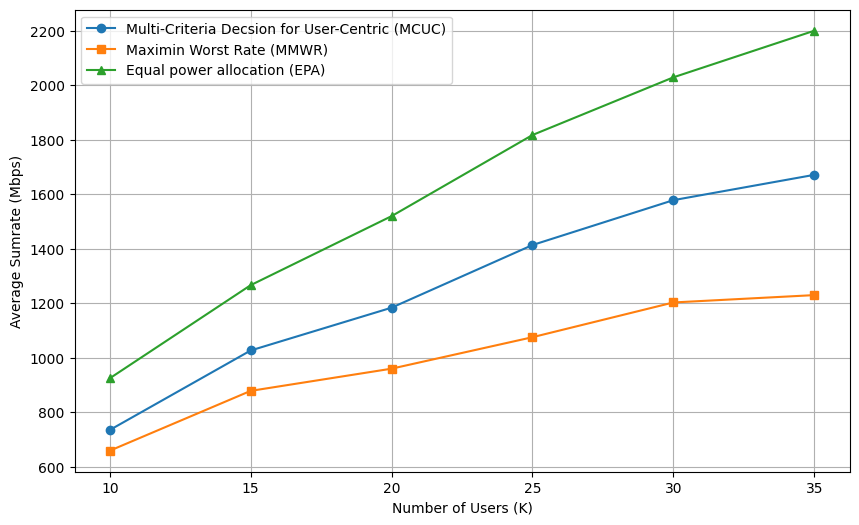

In [ ]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(user_counts, average_rates_case1, marker='o', label="Multi-Criteria Decsion for User-Centric (MCUC)")
plt.plot(user_counts, average_rates_case2, marker='s', label="Maximin Worst Rate (MMWR)")
plt.plot(user_counts, average_rates_case3, marker='^', label="Equal power allocation (EPA)")
# plt.plot(user_counts, average_rates_case4, marker='x', label="Random power allocation (RPA)")


# Add titles and labels
# plt.title("Average Rate for the User with the Worst Channel Across Different User Counts")
plt.xlabel("Number of Users (K)")
plt.ylabel("Average Sumrate (Mbps)")
plt.xticks(user_counts)
plt.grid(True)
plt.legend()
plt.savefig("Case2.png")
# Show the plot
plt.show()

In [ ]:
random_factors = np.random.rand(K)
random_power_mW = (random_factors / np.sum(random_factors)) * total_power_mW

random_rate = sum(random_power_mW )
print(random_rate)

200.00000000000006


In [ ]:
user_counts = [10,15,20,25,30,35]
control_alpha = [0.01,0.007,0.005,0.004, 0.0033,0.0028]

print(control_alpha[user_counts.index(10)])

0.01


## Ghép code

10
15
20
25
30
35


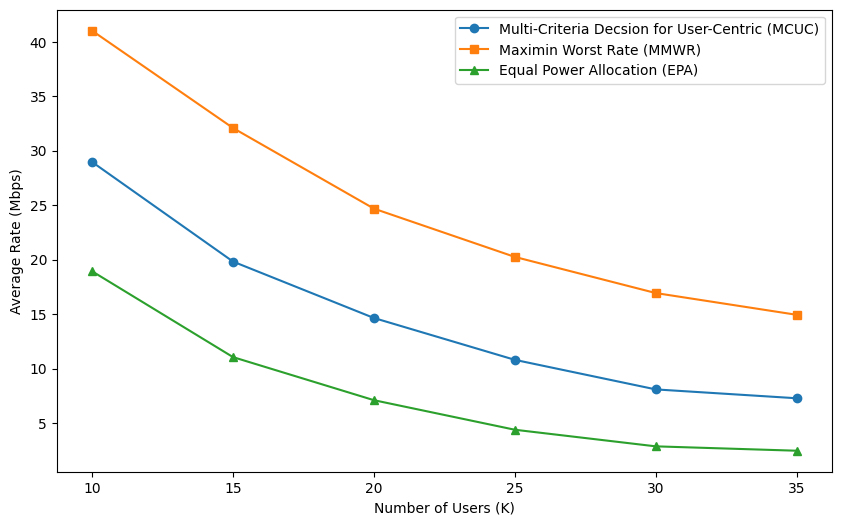


-----------------------------------------------------------


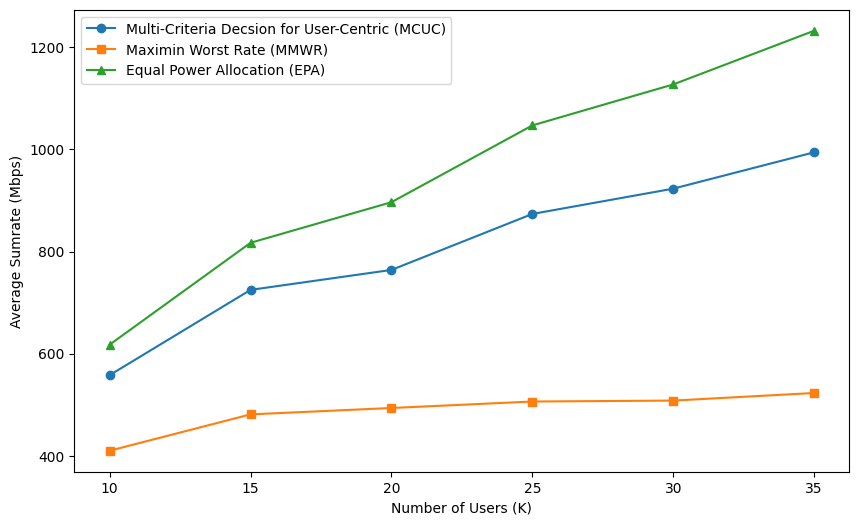

In [ ]:
import numpy as np
import cvxpy as cp
from scipy.io import loadmat
import matplotlib.pyplot as plt

# Parameters
M = 40  # Number of UAVs (USCs)
N = 20  # Number of antennas per UAV
Wband = 20e6  # Bandwidth = 20 MHz
total_power_mW = 200  # Total available power in mW
no_Monte = 100 # Number of Monte Carlo trials

# Load the .mat files containing location and path loss data
channel_data = loadmat('channel1.mat')
uav_user_path_data = loadmat('uavuserpath1.mat')

# Path loss data between UAVs and users
UAV_User_path = uav_user_path_data['UAV_User_path']
Noise_var = 290 * 1.38e-23 * Wband * 10**(9/10)  # Noise variance

# Compute beta_mk (large-scale fading)
beta_mk = UAV_User_path / Noise_var

# Define the user counts to test
user_counts = [10,15,20,25,30,35]
control_alpha = [0.01,0.007,0.005,0.004, 0.0033,0.0028]
# control_alpha = [0.03,0.021,0.015,0.012, 0.0099,0.0081]
control_alpha = [0.05,0.035,0.025,0.02, 0.0165,0.014]
# control_alpha = [0.04,0.0028,0.02,0.016, 0.0132,0.0084]
# Initialize the result arrays to store average rates for each case
average_rates_case1 = []
average_rates_case2 = []
average_rates_case3 = []
average_rates_case4 = []

average_sum_rates_case1 = []
average_sum_rates_case2 = []
average_sum_rates_case3 = []
average_sum_rates_case4 = []

# Monte Carlo simulation
for K in user_counts:
    print(K)
    # Initialize the result arrays to store rates for the user with the worst channel for this K
    worst_user_rates_case1 = np.zeros(no_Monte)
    worst_user_rates_case2 = np.zeros(no_Monte)
    worst_user_rates_case3 = np.zeros(no_Monte)
    worst_user_rates_case4 = np.zeros(no_Monte)

    sum_user_rates_case1 = np.zeros(no_Monte)
    sum_user_rates_case2 = np.zeros(no_Monte)
    sum_user_rates_case3 = np.zeros(no_Monte)
    sum_user_rates_case4 = np.zeros(no_Monte)

    for trial in range(no_Monte):
        # Compute the average channel gain (beta_hat) for each user
        beta_hat = np.mean(beta_mk[:K,:K], axis=0)
        # print(beta_hat.shape)
        # Identify the user with the worst channel
        user_k_kenh_te_nhat = np.argmin(beta_hat[:K])

        # Initialize matrix G with zeros for this trial
        G = np.zeros((M * N, K), dtype=complex)

        # Build the full G matrix for each UAV and user
        for m in range(M):
            h_mk = (1 / np.sqrt(2)) * (np.random.randn(N, K) + 1j * np.random.randn(N, K))
            g_mk = np.sqrt(beta_mk[m, :K]) * h_mk
            G[m * N: (m + 1) * N, :] = g_mk
            savemat('small_scale.mat', {
                'h_mk': h_mk})

        # Compute the Zero-Forcing beamforming matrix
        G_H = np.conjugate(G.T)
        GG_H = np.dot(G, G_H)
        GG_H_inv = np.linalg.inv(GG_H)
        Vzf = np.dot(G_H, GG_H_inv)


        gamma_k_list = []

        for k in range(K):
            G_k = G[:, k]  # Use the sorted index for each user
            v_k = Vzf.T[:, k]  # ZF beamforming vector for sorted user k
            norm_2 = np.linalg.norm(v_k, 2)
            f_k = (v_k / norm_2).reshape(-1, 1) # 800x1
            # print("f_k : ",f_k.shape)
            # print(G_k.shape)
            # print(f_k.shape)
            gamma_k = np.abs(np.dot(G_k.T, f_k))**2
            # print("gamma_k: ",gamma_k.shape)
            gamma_k_list.append(gamma_k)
        # print(gamma_k_list)
        for k in range (K):
            beta_hat[k] = gamma_k_list[k].item()
        # print(beta_hat)
        # Sort beta_hat and get the sorted indices
        sorted_indices = np.argsort(beta_hat)[::-1]  # Sorting in descending order
        sorted_beta_hat = beta_hat[sorted_indices]
        sort_indice_inv = sorted_indices[::-1]

        # Compute alpha_star based on the sorted beta_hat
        alpha_star = sorted_beta_hat / np.sum(sorted_beta_hat)
        alpha_star_order = np.zeros(K)

        # Re-map
        for k in range(K):
            alpha_star_order[sort_indice_inv[k]] = alpha_star[k]

        # Apply QoS constraint (minimum 0.05 for each channel)
        alpha_star_order = np.maximum(alpha_star_order, control_alpha[user_counts.index(K)])

        # Recalculate the remaining sum after applying the minimum threshold
        remaining_sum = 1 - np.sum(alpha_star_order[alpha_star_order == control_alpha[user_counts.index(K)]])

        # Normalize only the values that are greater than 0.05
        if remaining_sum > 0:
            alpha_star_order[alpha_star_order > control_alpha[user_counts.index(K)]] *= remaining_sum / np.sum(alpha_star_order[alpha_star_order > control_alpha[user_counts.index(K)]])

        # print(alpha_star_order)

        #### Case 1: Fairness of QoS ####
        P1 = cp.Variable(K)
        # sorted_indices = np.argsort(beta_hat)[::-1]  # Sorting in descending order
        # sorted_beta_hat = beta_hat[sorted_indices]
        # sort_indice_inv = sorted_indices[::-1]

        # # Compute alpha_star based on the sorted beta_hat
        # alpha_star = sorted_beta_hat / np.sum(sorted_beta_hat)

        # # Re-map
        # alpha_star_order = np.zeros(K)


        # for k in range(K):
        #     alpha_star_order[sort_indice_inv[k]] = alpha_star[k]


        rate_list_case1 = []
        # Objective and constraints for Case 1
        objective_case1 = 0
        for k in range(K):
            G_k = G[:, k]
            v_k = Vzf.T[:, k]
            norm_2 = np.linalg.norm(v_k, 2)
            f_k = (v_k / norm_2).reshape(-1, 1)
            gamma_k = np.abs(np.dot(G_k.T, f_k))**2 * P1[k]
            rate_k = Wband * cp.log(1 + gamma_k) / np.log(2)
            objective_case1 += alpha_star_order[k] * rate_k

        constraints_case1 = [cp.sum(P1) <= total_power_mW, P1 >= 0]
        problem_case1 = cp.Problem(cp.Maximize(objective_case1), constraints_case1)
        problem_case1.solve()

        # worst_user_rates_case1[trial] = rate_k.item() / 1e6  # Convert to Mbps
        for k in range(K):
            G_k = G[:, k]
            v_k = Vzf.T[:, k]
            norm_2 = np.linalg.norm(v_k, 2)
            f_k = (v_k / norm_2).reshape(-1, 1)
            gamma_k = np.abs(np.dot(G_k.T, f_k))**2 * P1.value[k] /1000
            rate_k = Wband * np.log(1 + gamma_k) / np.log(2)
            rate_list_case1.append(rate_k)
            # print(min(rate_list_case1)/1e6)
        worst_user_rates_case1[trial] = min(rate_list_case1).item() / 1e6
        sum_user_rates_case1[trial] = sum(rate_list_case1).item() / 1e6


        #### Case 2: Maximin SINR ####
        SINR_min = cp.Variable()
        SINR_list = []
        P2 = cp.Variable(K)
        rate_case2_list = []
        for k in range(K):
            G_k = G[:, k]
            v_k = Vzf.T[:, k]
            norm_2 = np.linalg.norm(v_k, 2)
            f_k = (v_k / norm_2).reshape(-1, 1)
            SINR_k = np.abs(np.dot(G_k.T, f_k))**2 * P2[k]
            SINR_list.append(SINR_k)

        objective_case2 = cp.Maximize(cp.min(cp.hstack(SINR_list)))
        constraints_case2 = [cp.sum(P2) <= total_power_mW, P2 >= 0]
        problem_case2 = cp.Problem(objective_case2, constraints_case2)
        problem_case2.solve()

        for k in range(K):
            G_k = G[:, k]
            v_k = Vzf.T[:, k]
            norm_2 = np.linalg.norm(v_k, 2)
            f_k = (v_k / norm_2).reshape(-1, 1)
            gamma_k = np.abs(np.dot(G_k.T, f_k))**2 * P2.value[k]/1000
            rate_k = Wband * np.log(1 + gamma_k) / np.log(2)
            rate_case2_list.append(rate_k)
            # sum_rate2 += rate_k

        worst_user_rates_case2[trial] = min(rate_case2_list).item() / 1e6  # Convert to Mbps
        sum_user_rates_case2[trial] = sum(rate_case2_list).item() / 1e6



        #### Case 3: Equal Power Allocation (EPA) ####
        equal_power_mW = total_power_mW / K
        equal_power_W = equal_power_mW / 1000
        rate_case3_list = []
        # Compute rate for the worst user in Case 3
        for k in range(K):
            G_k = G[:, k]
            v_k = Vzf.T[:, k]
            norm_2 = np.linalg.norm(v_k, 2)
            f_k = (v_k / norm_2).reshape(-1, 1)
            gamma_k = np.abs(np.dot(G_k.T, f_k))**2 * equal_power_W
            rate_k = Wband * np.log(1 + gamma_k) / np.log(2)
            rate_case3_list.append(rate_k)
            # sum_rate3 += rate_k

        worst_user_rates_case3[trial] = min(rate_case3_list).item() / 1e6  # Convert to Mbps
        sum_user_rates_case3[trial] = sum(rate_case3_list).item() / 1e6

        #### Case 4: Random Power Allocation ####
        random_factors = np.random.rand(K)
        random_power_mW = (random_factors / np.sum(random_factors)) * total_power_mW
        random_power_W = random_power_mW / 1000
        rate_case4_list =[]
        # Compute rate for the worst user in Case 4
        for k in range(K):
            G_k = G[:, k]
            v_k = Vzf.T[:, k]
            norm_2 = np.linalg.norm(v_k, 2)
            f_k = (v_k / norm_2).reshape(-1, 1)
            gamma_k = np.abs(np.dot(G_k.T, f_k))**2 * random_power_W[k]
            rate_k = Wband * np.log(1 + gamma_k) / np.log(2)
            rate_case4_list.append(rate_k)

        worst_user_rates_case4[trial] = min(rate_case4_list).item() / 1e6  # Convert to Mbps
        sum_user_rates_case4[trial] = sum(rate_case4_list).item() / 1e6

    # Calculate and store the average rates for this K
    average_rates_case1.append(np.mean(worst_user_rates_case1))
    average_rates_case2.append(np.mean(worst_user_rates_case2))
    average_rates_case3.append(np.mean(worst_user_rates_case3))
    average_rates_case4.append(np.mean(worst_user_rates_case4))


    average_sum_rates_case1.append(np.mean(sum_user_rates_case1))
    average_sum_rates_case2.append(np.mean(sum_user_rates_case2))
    average_sum_rates_case3.append(np.mean(sum_user_rates_case3))
    average_sum_rates_case4.append(np.mean(sum_user_rates_case4))
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(user_counts, average_rates_case1, marker='o', label="Multi-Criteria Decsion for User-Centric (MCUC)")
plt.plot(user_counts, average_rates_case2, marker='s', label="Maximin Worst Rate (MMWR)")
plt.plot(user_counts, average_rates_case3, marker='^', label="Equal Power Allocation (EPA)")
# plt.plot(user_counts, average_rates_case4, marker='x', label="Random power allocation (RPA)")


# Add titles and labels
# plt.title("Average Rate for the User with the Worst Channel Across Different User Counts")
plt.xlabel("Number of Users (K)")
plt.ylabel("Average Rate (Mbps)")
plt.xticks(user_counts)  # Set x-ticks to match the user counts
plt.grid(False)
plt.legend()
plt.savefig("Case1.png")
# Show the plot
plt.show()
print("")
print("-----------------------------------------------------------")

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(user_counts, average_sum_rates_case1, marker='o', label="Multi-Criteria Decsion for User-Centric (MCUC)")
plt.plot(user_counts, average_sum_rates_case2, marker='s', label="Maximin Worst Rate (MMWR)")
plt.plot(user_counts, average_sum_rates_case3, marker='^', label="Equal Power Allocation (EPA)")
# plt.plot(user_counts, average_sum_rates_case4, marker='x', label="Random power allocation (RPA)")


# Add titles and labels
# plt.title("Average Rate for the User with the Worst Channel Across Different User Counts")
plt.xlabel("Number of Users (K)")
plt.ylabel("Average Sumrate (Mbps)")
plt.xticks(user_counts)  # Set x-ticks to match the user counts
plt.grid(False)
plt.legend()
plt.savefig("Case2.png")
# Show the plot
plt.show()

# New Section

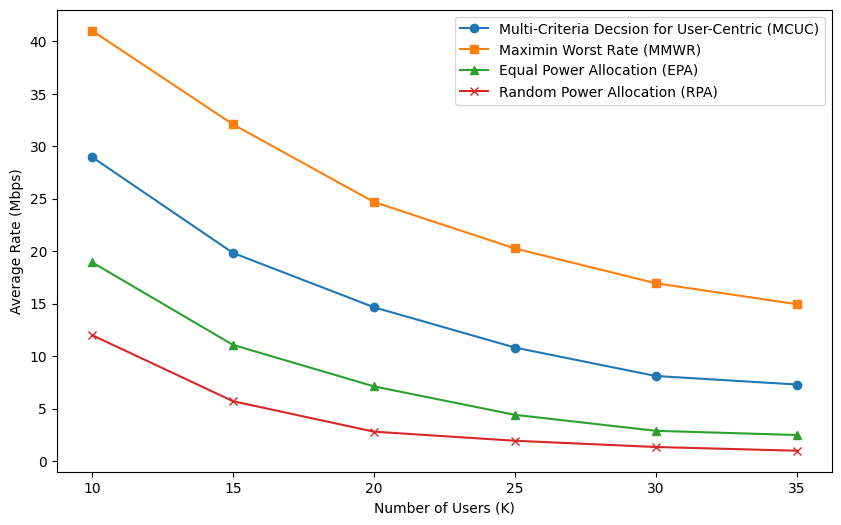


-----------------------------------------------------------


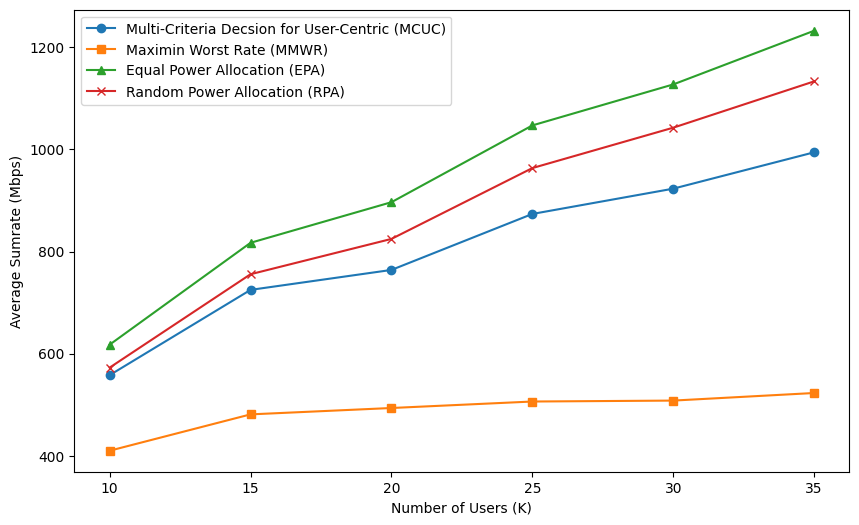

In [ ]:
# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(user_counts, average_rates_case1, marker='o', label="Multi-Criteria Decsion for User-Centric (MCUC)")
plt.plot(user_counts, average_rates_case2, marker='s', label="Maximin Worst Rate (MMWR)")
plt.plot(user_counts, average_rates_case3, marker='^', label="Equal Power Allocation (EPA)")
plt.plot(user_counts, average_rates_case4, marker='x', label="Random Power Allocation (RPA)")


# Add titles and labels
# plt.title("Average Rate for the User with the Worst Channel Across Different User Counts")
plt.xlabel("Number of Users (K)")
plt.ylabel("Average Rate (Mbps)")
plt.xticks(user_counts)  # Set x-ticks to match the user counts
plt.grid(False)
plt.legend()
plt.savefig("Case1_withrandom.png")
# Show the plot
plt.show()
print("")
print("-----------------------------------------------------------")

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(user_counts, average_sum_rates_case1, marker='o', label="Multi-Criteria Decsion for User-Centric (MCUC)")
plt.plot(user_counts, average_sum_rates_case2, marker='s', label="Maximin Worst Rate (MMWR)")
plt.plot(user_counts, average_sum_rates_case3, marker='^', label="Equal Power Allocation (EPA)")
plt.plot(user_counts, average_sum_rates_case4, marker='x', label="Random Power Allocation (RPA)")


# Add titles and labels
# plt.title("Average Rate for the User with the Worst Channel Across Different User Counts")
plt.xlabel("Number of Users (K)")
plt.ylabel("Average Sumrate (Mbps)")
plt.xticks(user_counts)  # Set x-ticks to match the user counts
plt.grid(False)
plt.legend()
plt.savefig("Case2_withrandom.png")
# Show the plot
plt.show()

# Add BFOA

In [ ]:
import numpy as np
from scipy.io import loadmat

# Load data
channel_data = loadmat('channel1.mat')
uav_user_path_data = loadmat('uavuserpath1.mat')
UAV_User_path = uav_user_path_data['UAV_User_path']

# Parameters
M = 40  # Number of UAVs (USCs)
N = 20  # Number of antennas per UAV
K = 10  # Number of users
Wband = 20e6  # Bandwidth = 20 MHz
total_power_mW = 200  # Total power in mW
Noise_var = 290 * 1.38e-23 * Wband * 10**(9/10)  # Noise variance
beta_mk = UAV_User_path / Noise_var

# QoS requirements: minimum power for each user
qos_power_min = np.random.uniform(0.01, 0.015, size=K)  # Minimum power in W for each user

# Initialize BFOA parameters
num_bacteria = 1000
num_iterations = 100
num_dim = K  # Power allocation per user
C = 0.05  # Step size for tumbling
power_limits = [qos_power_min, total_power_mW / 1000]  # Power limits in W

# Tính beta_hat và alpha_star một lần
beta_hat = np.mean(beta_mk, axis=0)
alpha_star = beta_hat / np.sum(beta_hat)

def fitness_function(p):
    """Calculate the fitness function for the given power allocation."""
    rate_sum = 0
    for k in range(K):
        G_k = np.sqrt(beta_mk[:, k]).reshape(-1, 1)  # Simplified channel gains
        interference = np.sum(G_k ** 2 * p) - G_k[k] ** 2 * p[k]
        SINR_k = (G_k[k] ** 2 * p[k]) / (interference + Noise_var)
        rate_k = Wband * np.log2(1 + SINR_k)
        rate_sum += alpha_star[k] * rate_k

    return -rate_sum  # Negative for minimization

# Initialize bacteria
bacteria_positions = np.random.uniform(
    power_limits[0], power_limits[1], size=(num_bacteria, num_dim)
)
fitness = np.array([fitness_function(bacteria_positions[i]) for i in range(num_bacteria)])
J_health = np.zeros(num_bacteria)  # Health of each bacterium

# BFOA process
def chemotaxis():
    global bacteria_positions, fitness, J_health
    for i in range(num_bacteria):
        # Tumbling
        delta = np.random.uniform(-1, 1, size=num_dim)
        delta /= np.linalg.norm(delta)  # Normalize direction
        new_position = bacteria_positions[i] + C * delta

        # Clamp power values within limits
        new_position = np.clip(new_position, power_limits[0], power_limits[1])

        # Evaluate fitness of the new position
        new_fitness = fitness_function(new_position)

        # Swim if fitness improves
        J_last = fitness[i]
        if new_fitness < J_last:
            bacteria_positions[i] = new_position
            fitness[i] = new_fitness
            J_health[i] += new_fitness
            # Swim
            for swim_step in range(4):  # Swim length is 4
                new_position += C * delta
                new_position = np.clip(new_position, power_limits[0], power_limits[1])
                new_fitness = fitness_function(new_position)
                if new_fitness < fitness[i]:
                    bacteria_positions[i] = new_position
                    fitness[i] = new_fitness
                    J_health[i] += new_fitness
                else:
                    break

def reproduction():
    global bacteria_positions, fitness, J_health
    sorted_indices = np.argsort(J_health)
    for i in range(num_bacteria // 2):
        bacteria_positions[sorted_indices[-(i + 1)]] = bacteria_positions[sorted_indices[i]]
        fitness[sorted_indices[-(i + 1)]] = fitness[sorted_indices[i]]
        J_health[sorted_indices[-(i + 1)]] = J_health[sorted_indices[i]]

def elimination_dispersal():
    global bacteria_positions, fitness, J_health
    for i in range(num_bacteria):
        if np.random.rand() < 0.1:  # Probability of elimination-dispersal
            bacteria_positions[i] = np.random.uniform(
                power_limits[0], power_limits[1], size=num_dim
            )
            fitness[i] = fitness_function(bacteria_positions[i])
            J_health[i] = 0

# Run BFOA
worst_user_rates = []
for iteration in range(num_iterations):
    chemotaxis()
    reproduction()
    elimination_dispersal()
    # Track the worst user's rate for this iteration
    worst_user_rate = -np.max(fitness)  # Maximize as fitness is negative weighted sum rate
    worst_user_rates.append(worst_user_rate)

# Best solution
best_index = np.argmin(fitness)
best_power_allocation = bacteria_positions[best_index]
best_fitness = -fitness[best_index]  # Convert back to positive

# Average worst rate across iterations
average_worst_rate = np.mean(worst_user_rates)

print("Best Power Allocation (W):", best_power_allocation)
print("Maximum Weighted Sum Rate (bps):", best_fitness)
print("Average Worst Rate among UCs (bps):", average_worst_rate)

<ipython-input-3-67c52052c5e0>:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  J_health[i] += new_fitness
<ipython-input-3-67c52052c5e0>:80: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  J_health[i] += new_fitness


Best Power Allocation (W): [0.0125915  0.2        0.01111862 0.01242323 0.01022752 0.2
 0.01010815 0.01267792 0.01154351 0.01174713]
Maximum Weighted Sum Rate (bps): [64593.5680839]
Average Worst Rate among UCs (bps): 23043.228164062264


In [ ]:
import numpy as np
from scipy.io import loadmat

# Load data
channel_data = loadmat('channel1.mat')
uav_user_path_data = loadmat('uavuserpath1.mat')
UAV_User_path = uav_user_path_data['UAV_User_path']

# Parameters
M = 40  # Number of UAVs (USCs)
N = 20  # Number of antennas per UAV
K = 10  # Number of users
Wband = 20e6  # Bandwidth = 20 MHz
total_power_mW = 200  # Total power in mW
Noise_var = 290 * 1.38e-23 * Wband * 10**(9/10)  # Noise variance
beta_mk = UAV_User_path / Noise_var

# QoS requirements: minimum power for each user
qos_power_min = np.random.uniform(0.01, 0.015, size=K)  # Minimum power in W for each user

# Initialize BFOA parameters
num_bacteria = 1000
num_iterations = 100
num_dim = K  # Power allocation per user
C = 0.05  # Step size for tumbling
power_limits = [qos_power_min, total_power_mW / 1000]  # Power limits in W

# Tính beta_hat và alpha_star một lần
beta_hat = np.mean(beta_mk, axis=0)
alpha_star = beta_hat / np.sum(beta_hat)

def fitness_function(p):
    """Calculate the fitness function for the given power allocation."""
    rate_sum = 0
    for k in range(K):
        G_k = np.sqrt(beta_mk[:, k]).reshape(-1, 1)  # Simplified channel gains
        interference = np.sum(G_k ** 2 * p) - G_k[k] ** 2 * p[k]
        SINR_k = (G_k[k] ** 2 * p[k]) / (interference + Noise_var)
        rate_k = Wband * np.log2(1 + SINR_k)
        rate_sum += alpha_star[k] * rate_k

    return -rate_sum  # Negative for minimization

# Initialize bacteria
bacteria_positions = np.random.uniform(
    power_limits[0], power_limits[1], size=(num_bacteria, num_dim)
)
fitness = np.array([fitness_function(bacteria_positions[i]) for i in range(num_bacteria)])
J_health = np.zeros(num_bacteria)  # Health of each bacterium

# BFOA process
def chemotaxis():
    global bacteria_positions, fitness, J_health
    for i in range(num_bacteria):
        # Tumbling
        delta = np.random.uniform(-1, 1, size=num_dim)
        delta /= np.linalg.norm(delta)  # Normalize direction
        new_position = bacteria_positions[i] + C * delta

        # Clamp power values within limits
        new_position = np.clip(new_position, power_limits[0], power_limits[1])

        # Evaluate fitness of the new position
        new_fitness = fitness_function(new_position)

        # Swim if fitness improves
        J_last = fitness[i]
        if new_fitness < J_last:
            bacteria_positions[i] = new_position
            fitness[i] = new_fitness
            J_health[i] += new_fitness.item()
            # Swim
            for swim_step in range(4):  # Swim length is 4
                new_position += C * delta
                new_position = np.clip(new_position, power_limits[0], power_limits[1])
                new_fitness = fitness_function(new_position)
                if new_fitness < fitness[i]:
                    bacteria_positions[i] = new_position
                    fitness[i] = new_fitness
                    J_health[i] += new_fitness.item()
                else:
                    break

def reproduction():
    global bacteria_positions, fitness, J_health
    sorted_indices = np.argsort(J_health)
    for i in range(num_bacteria // 2):
        bacteria_positions[sorted_indices[-(i + 1)]] = bacteria_positions[sorted_indices[i]]
        fitness[sorted_indices[-(i + 1)]] = fitness[sorted_indices[i]]
        J_health[sorted_indices[-(i + 1)]] = J_health[sorted_indices[i]]

def elimination_dispersal():
    global bacteria_positions, fitness, J_health
    for i in range(num_bacteria):
        if np.random.rand() < 0.1:  # Probability of elimination-dispersal
            bacteria_positions[i] = np.random.uniform(
                power_limits[0], power_limits[1], size=num_dim
            )
            fitness[i] = fitness_function(bacteria_positions[i])
            J_health[i] = 0

# Run BFOA
worst_user_rates = []
for iteration in range(num_iterations):
    chemotaxis()
    reproduction()
    elimination_dispersal()
    # Track the worst user's rate for this iteration
    worst_user_rate = -np.max(fitness)  # Maximize as fitness is negative weighted sum rate
    worst_user_rates.append(worst_user_rate)

# Best solution
best_index = np.argmin(fitness)
best_power_allocation = bacteria_positions[best_index]
best_fitness = -fitness[best_index]  # Convert back to positive

# Average worst rate across iterations
average_worst_rate = np.mean(worst_user_rates)

print("Best Power Allocation (W):", best_power_allocation)
print("Maximum Weighted Sum Rate (bps):", best_fitness)
print("Average Worst Rate among UCs (bps):", average_worst_rate)

Best Power Allocation (W): [0.01060163 0.2        0.0100035  0.01473119 0.01350727 0.2
 0.0147841  0.01485058 0.01418096 0.01114571]
Maximum Weighted Sum Rate (bps): [64042.58718675]
Average Worst Rate among UCs (bps): 23380.002206067777


In [ ]:
import numpy as np
from scipy.io import loadmat

# Load data
channel_data = loadmat('channel1.mat')
uav_user_path_data = loadmat('uavuserpath1.mat')
UAV_User_path = uav_user_path_data['UAV_User_path']

# Parameters
M = 40  # Number of UAVs (USCs)
N = 20  # Number of antennas per UAV
K = 10  # Number of users
Wband = 20e6  # Bandwidth = 20 MHz
total_power_mW = 200  # Total power in mW
Noise_var = 290 * 1.38e-23 * Wband * 10**(9/10)  # Noise variance
beta_mk = UAV_User_path / Noise_var

# QoS requirements: minimum power for each user
qos_power_min = np.random.uniform(0.01, 0.015, size=K)  # Minimum power in W for each user

# Initialize BFOA parameters
num_bacteria = 1000
num_iterations = 100
num_dim = K  # Power allocation per user
C = 0.05  # Step size for tumbling
power_limits = [qos_power_min, total_power_mW / 1000]  # Power limits in W

# Tính beta_hat và alpha_star một lần
beta_hat = np.mean(beta_mk, axis=0)
alpha_star = beta_hat / np.sum(beta_hat)

def fitness_function(p):
    """Calculate the fitness function for the given power allocation."""
    rate_sum = 0
    for k in range(K):
        G_k = np.sqrt(beta_mk[:, k]).reshape(-1, 1)  # Simplified channel gains
        interference = np.sum(G_k ** 2 * p) - G_k[k] ** 2 * p[k]
        SINR_k = (G_k[k] ** 2 * p[k]) / (interference + Noise_var)
        rate_k = Wband * np.log2(1 + SINR_k)
        rate_sum += alpha_star[k] * rate_k

    return -rate_sum  # Negative for minimization

# Initialize bacteria
bacteria_positions = np.random.uniform(
    power_limits[0], power_limits[1], size=(num_bacteria, num_dim)
)
fitness = np.array([fitness_function(bacteria_positions[i]) for i in range(num_bacteria)])
J_health = np.zeros(num_bacteria)  # Health of each bacterium

# BFOA process
def chemotaxis():
    global bacteria_positions, fitness, J_health
    for i in range(num_bacteria):
        # Tumbling
        delta = np.random.uniform(-1, 1, size=num_dim)
        delta /= np.linalg.norm(delta)  # Normalize direction
        new_position = bacteria_positions[i] + C * delta

        # Clamp power values within limits
        new_position = np.clip(new_position, power_limits[0], power_limits[1])

        # Evaluate fitness of the new position
        new_fitness = fitness_function(new_position)

        # Swim if fitness improves
        J_last = fitness[i]
        if new_fitness < J_last:
            bacteria_positions[i] = new_position
            fitness[i] = new_fitness
            J_health[i] += new_fitness.item()
            # Swim
            for swim_step in range(4):  # Swim length is 4
                new_position += C * delta
                new_position = np.clip(new_position, power_limits[0], power_limits[1])
                new_fitness = fitness_function(new_position)
                if new_fitness < fitness[i]:
                    bacteria_positions[i] = new_position
                    fitness[i] = new_fitness
                    J_health[i] += new_fitness.item()
                else:
                    break

def reproduction():
    global bacteria_positions, fitness, J_health
    sorted_indices = np.argsort(J_health)
    for i in range(num_bacteria // 2):
        bacteria_positions[sorted_indices[-(i + 1)]] = bacteria_positions[sorted_indices[i]]
        fitness[sorted_indices[-(i + 1)]] = fitness[sorted_indices[i]]
        J_health[sorted_indices[-(i + 1)]] = J_health[sorted_indices[i]]

def elimination_dispersal():
    global bacteria_positions, fitness, J_health
    for i in range(num_bacteria):
        if np.random.rand() < 0.1:  # Probability of elimination-dispersal
            bacteria_positions[i] = np.random.uniform(
                power_limits[0], power_limits[1], size=num_dim
            )
            fitness[i] = fitness_function(bacteria_positions[i])
            J_health[i] = 0

# Run BFOA
worst_user_rates = []
average_sum_rates = []
for iteration in range(num_iterations):
    chemotaxis()
    reproduction()
    elimination_dispersal()
    # Track the worst user's rate for this iteration
    worst_user_rate = -np.max(fitness)  # Maximize as fitness is negative weighted sum rate
    worst_user_rates.append(worst_user_rate)

    # Calculate the average sum rate for this iteration
    sum_rate = 0
    for i in range(num_bacteria):
        position = bacteria_positions[i]
        rate_sum = 0
        for k in range(K):
            G_k = np.sqrt(beta_mk[:, k]).reshape(-1, 1)  # Simplified channel gains
            interference = np.sum(G_k ** 2 * position) - G_k[k] ** 2 * position[k]
            SINR_k = (G_k[k] ** 2 * position[k]) / (interference + Noise_var)
            rate_k = Wband * np.log2(1 + SINR_k)
            rate_sum += rate_k
        sum_rate += rate_sum
    average_sum_rate = sum_rate / num_bacteria
    average_sum_rates.append(average_sum_rate)

# Best solution
best_index = np.argmin(fitness)
best_power_allocation = bacteria_positions[best_index]
best_fitness = -fitness[best_index]  # Convert back to positive

# Average worst rate across iterations
average_worst_rate = np.mean(worst_user_rates)

print("Best Power Allocation (W):", best_power_allocation)
print("Maximum Weighted Sum Rate (bps):", best_fitness)
print("Average Worst Rate among UCs (bps):", average_worst_rate)
print("Average Sum Rate (bps):", np.mean(average_sum_rates))


<ipython-input-6-d8d4db2ec2c7>:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  J_health[i] += new_fitness
<ipython-input-6-d8d4db2ec2c7>:80: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  J_health[i] += new_fitness


Best Power Allocation (W): [0.01469785 0.2        0.0112001  0.01131916 0.01004818 0.2
 0.0132775  0.01462274 0.01051807 0.01086429]
Maximum Weighted Sum Rate (bps): [64485.06450008]
Average Worst Rate among UCs (bps): 22947.14943134111
Average Sum Rate (bps): 2006605.518874705


## Ghép code lớn

10
case1:  [0.02465138 0.01548732 0.01432581 0.01861889 0.02445552 0.01676106
 0.02701515 0.02117036 0.02072077 0.01679372]
case2:  [0.01586417 0.02440107 0.02614421 0.02064495 0.01598499 0.02272696
 0.01453345 0.01832062 0.01869268 0.02268691]
case3:  0.02
case4:  [0.0081553  0.02518708 0.02160984 0.00196597 0.02661661 0.02948959
 0.01407424 0.02289781 0.00740031 0.04260324]
case5:  [0.01137133 0.00899713 0.01120245 0.01358864 0.01259848 0.01165243
 0.0129773  0.00874882 0.03255888 0.07630455]
case1:  [0.02465138 0.01548732 0.01432581 0.01861889 0.02445552 0.01676106
 0.02701515 0.02117036 0.02072077 0.01679372]
case2:  [0.01586417 0.02440107 0.02614421 0.02064495 0.01598499 0.02272696
 0.01453345 0.01832062 0.01869268 0.02268691]
case3:  0.02
case4:  [0.00010992 0.02548313 0.03015729 0.01631644 0.02703494 0.01375914
 0.03053503 0.01633623 0.01463654 0.02563133]
case5:  [0.0112478  0.01629708 0.00972758 0.0080814  0.00833494 0.01121652
 0.00967766 0.01082292 0.05509659 0.0594975 ]
cas

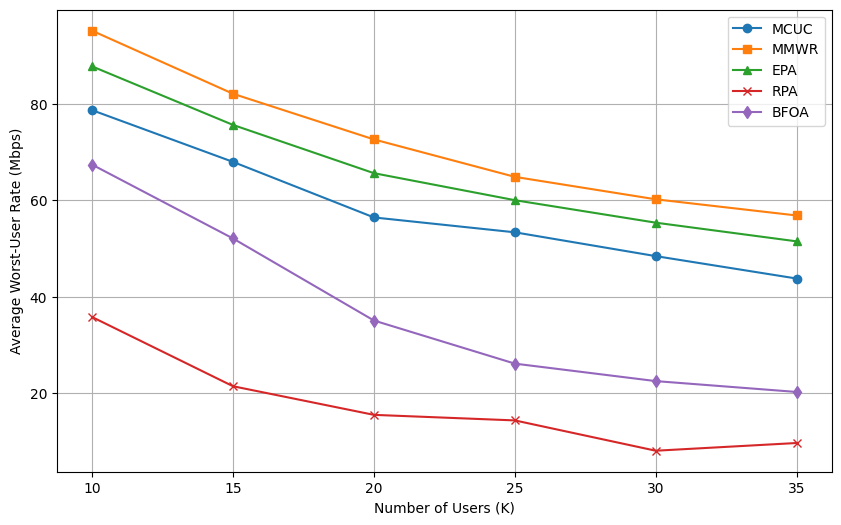

------------------------------


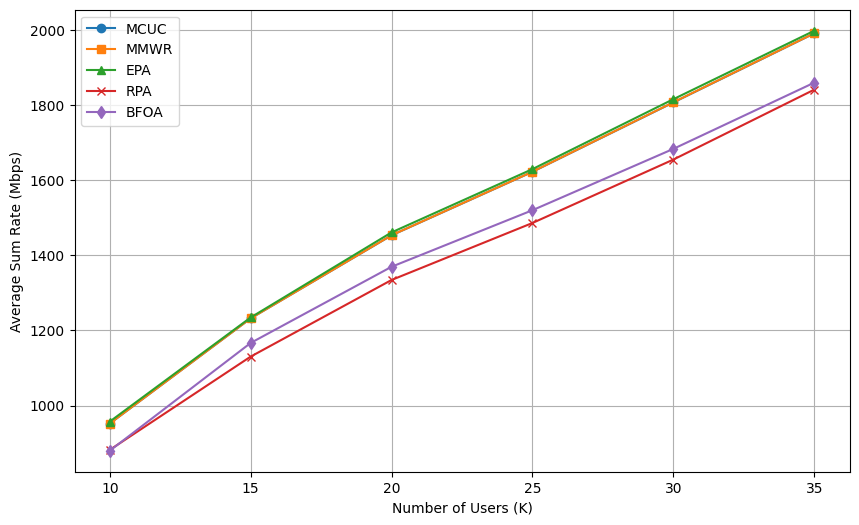

In [ ]:
import numpy as np
import cvxpy as cp
from scipy.io import loadmat, savemat
import matplotlib.pyplot as plt

# Parameters
M = 40  # Number of UAVs (USCs)
N = 20  # Number of antennas per UAV
Wband = 20e6  # Bandwidth = 20 MHz
total_power_mW = 200  # Total available power in mW
no_Monte = 20

# Load the .mat files containing location and path loss data
channel_data = loadmat('channel1.mat')
uav_user_path_data = loadmat('uavuserpath1.mat')

# Path loss data between UAVs and users
UAV_User_path = uav_user_path_data['UAV_User_path']
Noise_var = 290 * 1.38e-23 * Wband * 10**(9/10)  # Noise variance

# Compute beta_mk (large-scale fading)
beta_mk = UAV_User_path / Noise_var

# Define the user counts to test
user_counts = [10, 15, 20, 25, 30, 35]

# BFOA parameters
num_bacteria = 500
num_iterations = 50
C = 0.05  # Step size for tumbling
d_attract = 0.1
w_attract = 0.2
h_repel = 0.1
w_repel = 0.1


# Initialize result arrays
average_rates_case1, average_rates_case2, average_rates_case3, average_rates_case4, average_rates_case5 = [], [], [], [], []
average_sum_rates_case1, average_sum_rates_case2, average_sum_rates_case3, average_sum_rates_case4, average_sum_rates_case5 = [], [], [], [], []

def swarming_cost(theta, bacteria_positions):
    """
    Calculate the swarming cost based on cell-to-cell signaling.
    """
    swarm_cost = 0
    for i in range(len(bacteria_positions)):
        attract_term = -d_attract * np.exp(-w_attract * np.sum((theta - bacteria_positions[i]) ** 2))
        repel_term = h_repel * np.exp(-w_repel * np.sum((theta - bacteria_positions[i]) ** 2))
        swarm_cost += attract_term + repel_term
    return swarm_cost

def fitness_function(p, K, beta_mk, alpha_star, bacteria_positions):
    """
    Calculate the fitness function for the given power allocation.
    Includes swarming cost.
    """
    rate_sum = 0
    for k in range(K):
        G_k = np.sqrt(beta_mk[:, k]).reshape(-1, 1)  # Simplified channel gains
        interference = np.sum(G_k ** 2 * p) - G_k[k] ** 2 * p[k]
        SINR_k = (G_k[k] ** 2 * p[k]) / (interference + Noise_var)
        rate_k = Wband * np.log2(1 + SINR_k)
        rate_sum += alpha_star[k] * rate_k
    # Add swarming cost
    swarm_cost = swarming_cost(p, bacteria_positions)
    return -rate_sum + swarm_cost  # Negative for minimization

def bfoa_optimization(K, beta_mk, alpha_star):
    total_power_W = total_power_mW / 1000  # Convert total power to Watts
    power_limits = [np.random.uniform(0.01, 0.015, size=K), total_power_W]

    # Initialize bacteria
    bacteria_positions = np.random.uniform(power_limits[0], power_limits[1], size=(num_bacteria, K))
    for i in range(num_bacteria):
        bacteria_positions[i] = bacteria_positions[i] / np.sum(bacteria_positions[i]) * total_power_W

    fitness = np.array([fitness_function(bacteria_positions[i], K, beta_mk, alpha_star, bacteria_positions)
                        for i in range(num_bacteria)])

    for iteration in range(num_iterations):
        for i in range(num_bacteria):
            delta = np.random.uniform(-1, 1, size=K)
            delta /= np.linalg.norm(delta)
            new_position = bacteria_positions[i] + C * delta
            new_position = np.clip(new_position, power_limits[0], power_limits[1])

            # Normalize to ensure total power constraint
            new_position = new_position / np.sum(new_position) * total_power_W

            new_fitness = fitness_function(new_position, K, beta_mk, alpha_star, bacteria_positions)
            if new_fitness < fitness[i]:
                bacteria_positions[i] = new_position
                fitness[i] = new_fitness

        # Reproduction
        J_health = np.argsort(fitness)
        for i in range(num_bacteria // 2):
            bacteria_positions[J_health[-(i + 1)]] = bacteria_positions[J_health[i]]
            fitness[J_health[-(i + 1)]] = fitness[J_health[i]]

        # Elimination and dispersal
        for i in range(num_bacteria):
            if np.random.rand() < 0.1:
                bacteria_positions[i] = np.random.uniform(power_limits[0], power_limits[1], size=K)
                bacteria_positions[i] = bacteria_positions[i] / np.sum(bacteria_positions[i]) * total_power_W
                fitness[i] = fitness_function(bacteria_positions[i], K, beta_mk, alpha_star, bacteria_positions)

    best_index = np.argmin(fitness)
    best_allocation = bacteria_positions[best_index]
    best_fitness = -fitness[best_index]
    return best_allocation, best_fitness


# Monte Carlo simulation
for K in user_counts:
    print(K)
    worst_user_rates_case1 = np.zeros(no_Monte)
    worst_user_rates_case2 = np.zeros(no_Monte)
    worst_user_rates_case3 = np.zeros(no_Monte)
    worst_user_rates_case4 = np.zeros(no_Monte)
    worst_user_rates_case5 = np.zeros(no_Monte)

    sum_user_rates_case1 = np.zeros(no_Monte)
    sum_user_rates_case2 = np.zeros(no_Monte)
    sum_user_rates_case3 = np.zeros(no_Monte)
    sum_user_rates_case4 = np.zeros(no_Monte)
    sum_user_rates_case5 = np.zeros(no_Monte)

    for trial in range(no_Monte):
        beta_hat = np.mean(beta_mk[:K, :K], axis=0)
        alpha_star = beta_hat / np.sum(beta_hat)

        # Case 1: Multi-Criteria Decision for User-Centric (MCUC)
        P1 = cp.Variable(K)
        objective_case1 = cp.Maximize(cp.sum(cp.multiply(alpha_star, Wband * cp.log(1 + cp.multiply(beta_hat, P1)) / np.log(2))))
        constraints_case1 = [cp.sum(P1) <= total_power_mW / 1000, P1 >= 0]
        problem_case1 = cp.Problem(objective_case1, constraints_case1)
        problem_case1.solve()
        worst_user_rates_case1[trial] = min(Wband * np.log2(1 + beta_hat * P1.value) / 1e6)
        sum_user_rates_case1[trial] = sum(Wband * np.log2(1 + beta_hat * P1.value) / 1e6)
        print("case1: ",P1.value)
        # Case 2: Maximin Worst Rate (MMWR)
        P2 = cp.Variable(K)
        SINR_min = cp.Variable()
        constraints_case2 = [P2 >= 0, cp.sum(P2) <= total_power_mW / 1000]
        for k in range(K):
            constraints_case2.append(SINR_min <= beta_hat[k] * P2[k])
        objective_case2 = cp.Maximize(SINR_min)
        problem_case2 = cp.Problem(objective_case2, constraints_case2)
        problem_case2.solve()
        worst_user_rates_case2[trial] = min(Wband * np.log2(1 + beta_hat * P2.value) / 1e6)
        sum_user_rates_case2[trial] = sum(Wband * np.log2(1 + beta_hat * P2.value) / 1e6)
        print("case2: ",P2.value)

        # Case 3: Equal Power Allocation (EPA)
        equal_power_W = total_power_mW / (1000 * K)
        print("case3: ",equal_power_W)
        rates_case3 = Wband * np.log2(1 + beta_hat * equal_power_W) / 1e6
        worst_user_rates_case3[trial] = min(rates_case3)
        sum_user_rates_case3[trial] = sum(rates_case3)

        # Case 4: Random Power Allocation (RPA)
        random_factors = np.random.rand(K)
        random_power_allocation = (random_factors / sum(random_factors)) * (total_power_mW / 1000)
        print("case4: ",random_power_allocation)
        rates_case4 = Wband * np.log2(1 + beta_hat * random_power_allocation) / 1e6
        worst_user_rates_case4[trial] = min(rates_case4)
        sum_user_rates_case4[trial] = sum(rates_case4)

        # Case 5: BFOA Optimization
        best_allocation, _ = bfoa_optimization(K, beta_mk[:K, :K], alpha_star)
        # rate_case5_list = []
        # for k in range(K):
        #     # G_k = np.sqrt(beta_mk[:, k]).reshape(-1, 1)
        #     # interference = np.sum(G_k ** 2 * best_allocation) - G_k[k] ** 2 * best_allocation[k]
        #     # SINR_k = (G_k[k] ** 2 * best_allocation[k]) / (interference + Noise_var)
        #     # rate_k = Wband * np.log2(1 + SINR_k)
        #     rate_case5_list.append(rate_k)
        rates_case5 = Wband * np.log2(1 + beta_hat * best_allocation) / 1e6
        # print(rates_case5)
        worst_user_rates_case5[trial] = min(rates_case5)
        sum_user_rates_case5[trial] = sum(rates_case5)
        print("case5: ",best_allocation)

        # worst_user_rates_case5.append(min(rate_case5_list) / 1e6)
        # sum_user_rates_case5.append(sum(rate_case5_list) / 1e6)

    average_rates_case1.append(np.mean(worst_user_rates_case1))
    average_rates_case2.append(np.mean(worst_user_rates_case2))
    average_rates_case3.append(np.mean(worst_user_rates_case3))
    average_rates_case4.append(np.mean(worst_user_rates_case4))
    average_rates_case5.append(np.mean(worst_user_rates_case5))

    average_sum_rates_case1.append(np.mean(sum_user_rates_case1))
    average_sum_rates_case2.append(np.mean(sum_user_rates_case2))
    average_sum_rates_case3.append(np.mean(sum_user_rates_case3))
    average_sum_rates_case4.append(np.mean(sum_user_rates_case4))
    average_sum_rates_case5.append(np.mean(sum_user_rates_case5))

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(user_counts, average_rates_case1, marker='o', label="MCUC")
plt.plot(user_counts, average_rates_case2, marker='s', label="MMWR")
plt.plot(user_counts, average_rates_case3, marker='^', label="EPA")
plt.plot(user_counts, average_rates_case4, marker='x', label="RPA")
plt.plot(user_counts, average_rates_case5, marker='d', label="BFOA")
plt.xlabel("Number of Users (K)")
plt.ylabel("Average Worst-User Rate (Mbps)")
plt.xticks(user_counts)
plt.grid(True)
plt.legend()
plt.savefig("Case_Comparison_WorstRate.png")
plt.show()

print("------------------------------")

plt.figure(figsize=(10, 6))
plt.plot(user_counts, average_sum_rates_case1, marker='o', label="MCUC")
plt.plot(user_counts, average_sum_rates_case2, marker='s', label="MMWR")
plt.plot(user_counts, average_sum_rates_case3, marker='^', label="EPA")
plt.plot(user_counts, average_sum_rates_case4, marker='x', label="RPA")
plt.plot(user_counts, average_sum_rates_case5, marker='d', label="BFOA")
plt.xlabel("Number of Users (K)")
plt.ylabel("Average Sum Rate (Mbps)")
plt.xticks(user_counts)
plt.grid(True)
plt.legend()
plt.savefig("Case_Comparison_SumRate.png")
plt.show()

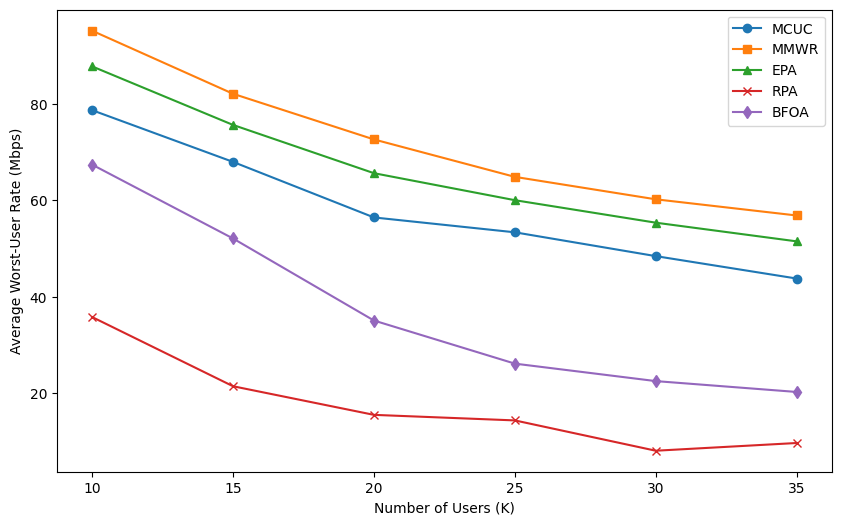

------------------------------


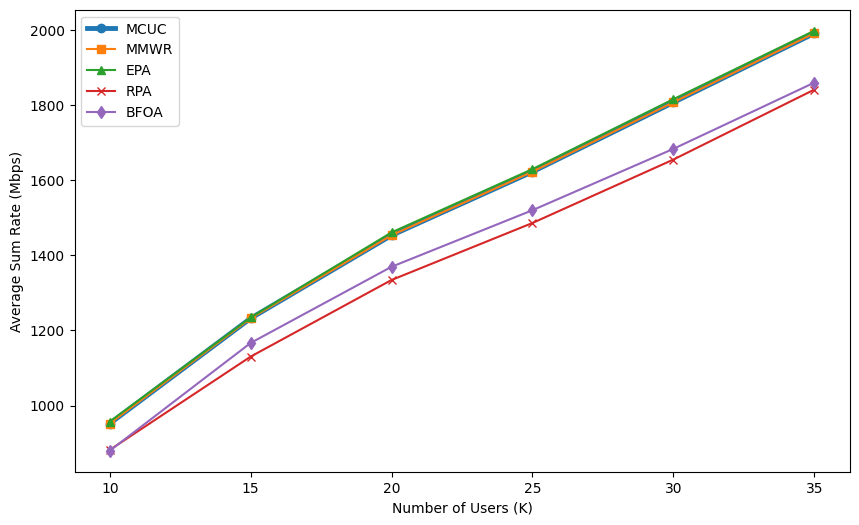

In [ ]:
# Plot results
plt.figure(figsize=(10, 6))
plt.plot(user_counts, average_rates_case1, marker='o', label="MCUC")
plt.plot(user_counts, average_rates_case2, marker='s', label="MMWR")
plt.plot(user_counts, average_rates_case3, marker='^', label="EPA")
plt.plot(user_counts, average_rates_case4, marker='x', label="RPA")
plt.plot(user_counts, average_rates_case5, marker='d', label="BFOA")
plt.xlabel("Number of Users (K)")
plt.ylabel("Average Worst-User Rate (Mbps)")
plt.xticks(user_counts)
# plt.grid(True)
plt.legend()
plt.savefig("Case_Comparison_WorstRate1.eps")
plt.show()

print("------------------------------")

plt.figure(figsize=(10, 6))
plt.plot(user_counts, average_sum_rates_case1, marker='o', linewidth=3.5, label="MCUC")
plt.plot(user_counts, average_sum_rates_case2, marker='s', label="MMWR")
plt.plot(user_counts, average_sum_rates_case3, marker='^', label="EPA")
plt.plot(user_counts, average_sum_rates_case4, marker='x', label="RPA")
plt.plot(user_counts, average_sum_rates_case5, marker='d', label="BFOA")
plt.xlabel("Number of Users (K)")
plt.ylabel("Average Sum Rate (Mbps)")
plt.xticks(user_counts)
# plt.grid(True)
plt.legend()
plt.savefig("Case_Comparison_SumRate1.eps")
plt.show()